# RSoXR Batch Fitting – Example Notebook

This notebook demonstrates the full RSoXR fitting workflow using the current codebase.

**Workflow overview**
1. Imports and environment setup
2. Load SLD arrays from NEXAFS analysis
3. Load experimental reflectivity data
4. Define model structure (layer stack, parameters, bounds)
5. Generate batch models
6. Preview models before fitting
7. Adjust bounds interactively (optional)
8. Run batch fit
9. Inspect results
10. Save / reload results

## 1. Imports and environment

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import sys
sys.path.append('/homes/dfs1/Refltools')  # adjust to your tools path

import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
from copy import deepcopy
import pandas as pd
import refnx

from refnx.dataset import ReflectDataset, Data1D

# --- Core fitting ---
from Model_Setup import (
    create_reflectometry_model,
    create_model_and_objective,
    run_fitting,
    print_fit_results,
    SLDinterp,
    generate_sld_array_from_material,
    update_objective,
    update_objective_with_plotting,
    save_batch_fit_results,
    load_batch_fit_results,
    extract_sld_from_objectives,
    save_material_sld,
    load_material_sld_array,
    load_fitting_file,
    extract_objective,
    extract_structure,
    plot_material_sld,
)

# --- Batch pipeline ---
from batch import (
    import_batch_reflectivity,
    generate_materials_from_sld_arrays,
    generate_layer_params_with_flexible_bounds,
    generate_batch_models,
    simulate_reflectivity_profiles,
    batch_fit_selected_models,
    extract_results_from_objectives,
    batch_update_parameter_bounds,
    export_parameter_bounds,
    export_best_parameters,
)

# --- Visualisation ---
from NEXAFS_RSoXR import (
    visualize_batch_models,
    visualize_fit_results,
    create_interactive_model_visualizer,
    create_multi_energy_comparison,
    interactive_parameter_explorer,
    create_vscode_parameter_explorer,
    create_vscode_before_after_explorer,
    create_interactive_parameter_updater_v3,
    plot_optical_constants_comparison,
    plot_simulated_reflectivity_and_sld,
    analyze_model_parameters_by_energy,
    plot_parameter_energy_trends,
)
from Plotting_Refl import modelcomparisonplot, profileflip

# --- NEXAFS ---
from NEXAFS import load_spectrum_data, plot_spectra, process_nexafs_to_SLD

print(f'refnx: {refnx.__version__}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
refnx: 0.1.42.dev0+4d05296


## 2. Load SLD arrays

SLD arrays are three-column CSVs: `[Energy_eV, Real_SLD, Imag_SLD]`.
They are typically produced upstream by NEXAFS analysis and saved with
`save_material_sld()`.

Loaded SLD data from /homes/dfs1/Reflectivity/INT_MOX/SLD_Fits/IntelA_Nov2025_MOX_Nov2025_M1_Rd5.csv  shape=(40, 3)
  Energy: 282.0–330.0 eV
Loaded SLD data from /homes/dfs1/Reflectivity/INT_MOX/SLD_Fits/IntelA_Nov2025_UL_Nov2025_M1_Rd5.csv  shape=(40, 3)
  Energy: 282.0–330.0 eV


(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'Real Component'}, xlabel='Energy (eV)', ylabel='Delta (Real SLD)'>,
        <Axes: title={'center': 'Imaginary Component'}, xlabel='Energy (eV)', ylabel='Beta (Imag SLD)'>,
        <Axes: title={'center': 'Binary Contrast'}, xlabel='Energy (eV)', ylabel='Contrast'>],
       dtype=object))

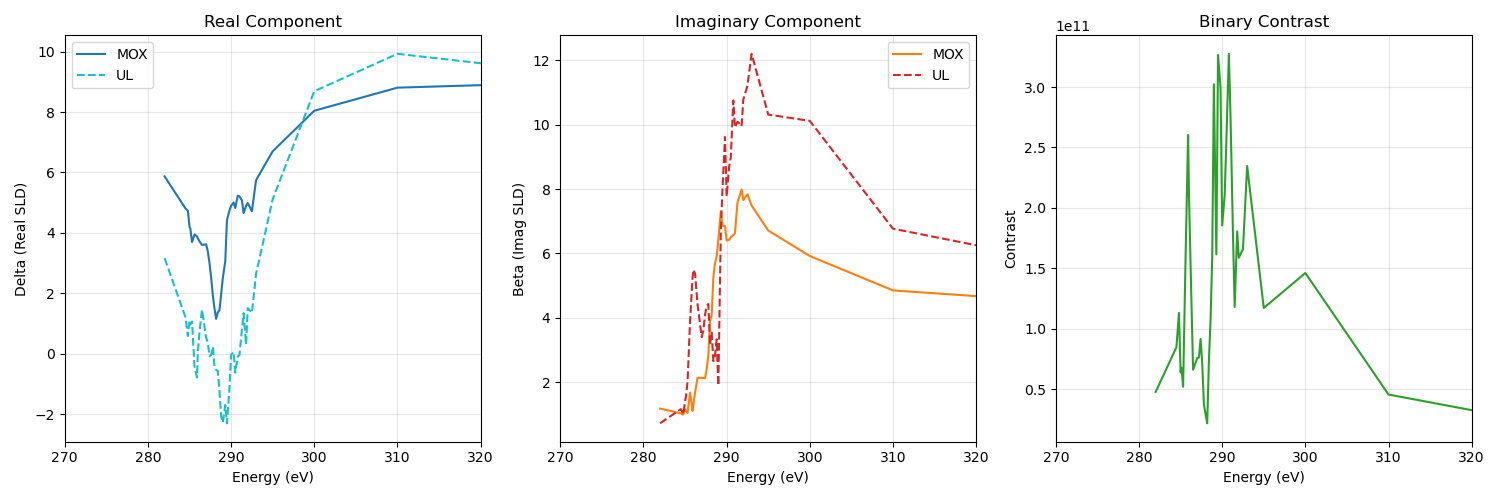

In [2]:
# Paths to SLD CSV files – adjust to your data location
Si_File='/homes/dfs1/Refltools/OC/Si_SLD.txt'
SiO2_File='/homes/dfs1/Refltools/OC/SiO2_Dean_SLD.txt'

Si_SLD    = np.loadtxt('/homes/dfs1/Refltools/OC/Si_SLD.txt')     # tabulated, columns: E, Re, Im
SiO2_SLD  = np.loadtxt('/homes/dfs1/Refltools/OC/SiO2_Dean_SLD.txt')
MOX_SLD   = load_material_sld_array('/homes/dfs1/Reflectivity/INT_MOX/SLD_Fits/IntelA_Nov2025_MOX_Nov2025_M1_Rd5.csv')
UL_SLD    = load_material_sld_array('/homes/dfs1/Reflectivity/INT_MOX/SLD_Fits/IntelA_Nov2025_UL_Nov2025_M1_Rd5.csv')

# Collect into a single dict keyed by material name.
# Every material that varies with energy must appear here.
material_sld_arrays = {
    'Si':   Si_SLD,
    'SiO2': SiO2_SLD,
    'MOX':  MOX_SLD,
    'UL':   UL_SLD,
}

# Optional: preview the SLD dispersion for one material
plot_optical_constants_comparison(
    n1_array=MOX_SLD,
    n2_array=UL_SLD,
    labels=['MOX', 'UL'],
    x_limits=(270, 320),   # Carbon K-edge region
)

## 3. Load experimental reflectivity data

`import_batch_reflectivity` scans a folder for `.dat` files and extracts
the energy from the filename (e.g. `Sample_285.0eV_smoothed.dat`).

In [3]:
DATA_DIR = '/homes/dfs1/Reflectivity/INT_MOX/RSoXR_Data/Nov/IntelB/Carbon_Comb'

data_dict, energy_list = import_batch_reflectivity(
    folder_path=DATA_DIR,
    file_type='all',   # 'raw', 'smoothed', or 'all'
)

print(f'\nLoaded {len(energy_list)} datasets')
print(f'Energies: {energy_list}')

Loaded IntelB_270.0eV.dat  (270.0 eV)
Loaded IntelB_282.0eV.dat  (282.0 eV)
Loaded IntelB_285.0eV.dat  (285.0 eV)
Loaded IntelB_286.0eV.dat  (286.0 eV)
Loaded IntelB_287.0eV.dat  (287.0 eV)
Loaded IntelB_288.0eV.dat  (288.0 eV)
Loaded IntelB_289.0eV.dat  (289.0 eV)
Loaded IntelB_290.0eV.dat  (290.0 eV)
Loaded IntelB_291.0eV.dat  (291.0 eV)
Loaded IntelB_292.0eV.dat  (292.0 eV)
Loaded IntelB_293.0eV.dat  (293.0 eV)
Loaded IntelB_295.0eV.dat  (295.0 eV)
Loaded IntelB_300.0eV.dat  (300.0 eV)
Loaded IntelB_310.0eV.dat  (310.0 eV)
Loaded IntelB_330.0eV.dat  (330.0 eV)
Loaded IntelB_284.5eV.dat  (284.5 eV)
Loaded IntelB_284.8eV.dat  (284.8 eV)
Loaded IntelB_285.1eV.dat  (285.1 eV)
Loaded IntelB_285.3eV.dat  (285.3 eV)
Loaded IntelB_285.6eV.dat  (285.6 eV)
Loaded IntelB_285.9eV.dat  (285.9 eV)
Loaded IntelB_286.2eV.dat  (286.2 eV)
Loaded IntelB_286.5eV.dat  (286.5 eV)
Loaded IntelB_287.2eV.dat  (287.2 eV)
Loaded IntelB_287.4eV.dat  (287.4 eV)
Loaded IntelB_287.6eV.dat  (287.6 eV)
Loaded Intel

## 4. Define model structure

### Layer parameters

For each layer, supply initial values and optionally bounds:
- `thickness` / `roughness` – initial values in Å
- `thickness_bounds` / `roughness_bounds` – `(lower, upper, vary)`
- `sld_real_bounds` / `sld_imag_bounds` – explicit SLD bounds
  (overrides `sld_offset_bounds` below)

### SLD offset bounds

For materials whose SLD varies with energy (derived from SLD arrays),
you can specify offsets relative to the interpolated value:
```python
sld_offset_bounds = {
    'MOX': {'real': (-1.0, 0.5, True), 'imag': (-0.2, 1.0, True)}
}
```
This sets `sld_real_bounds = (interpolated_real - 1.0, interpolated_real + 0.5, True)`
at each energy.  Materials not listed here are fixed at their interpolated values.

In [4]:
# ── Layer parameter template ──────────────────────────────────────────────
# Layers not listed in sld_offset_bounds below will have their SLD fixed
# at the interpolated value from the SLD array.

layer_params = {
    'Si': {
        'thickness': 0,  'roughness': 5,
        'thickness_bounds': (0, 0, False),
        'roughness_bounds': (3, 7, False),
    },
    'SiO2': {
        'thickness': 17,  'roughness': 3,
        'thickness_bounds': (14, 22, True),
        'roughness_bounds': (1, 6,  True),
    },
    'UL': {
        'thickness': 93,  'roughness': 5,
        'thickness_bounds': (88, 98, True),
        'roughness_bounds': (2, 9,  True),
    },
    'MOX': {
        'thickness': 180, 'roughness': 10,
        'thickness_bounds': (175, 185, True),
        'roughness_bounds': (7,   14,  True),
    },
    'air': {
        'thickness': 0, 'roughness': 0,
        'sld_real_bounds': (0, 0, False),
        'sld_imag_bounds': (0, 0, False),
        'thickness_bounds': (0, 0, False),
        'roughness_bounds': (0, 0, False),
    },
}

# ── SLD offset bounds for energy-varying materials ────────────────────────
sld_offset_bounds = {
    'UL':  {'real': (-3.0, 3.0, True), 'imag': (-3.0, 3.0, True)},
    'MOX': {'real': (-1.0, 0.5, True), 'imag': (-0.2, 1.0, True)},
}

# ── Layer order: top (air) → bottom (Si) ─────────────────────────────────
layer_order = ['air', 'MOX', 'UL', 'SiO2', 'Si']

## 5. Generate batch models

`generate_batch_models` runs the full pipeline:
SLD interpolation → layer params → `create_reflectometry_model` → `create_model_and_objective`
for every energy in `energy_list`.

In [5]:
models_dict, structures_dict, objectives_dict = generate_batch_models(
    data_dict=data_dict,
    energy_list=[270,282],
    material_sld_arrays=material_sld_arrays,
    constant_materials=None,       # air already defined in layer_params
    base_layer_params=layer_params,
    layer_order=layer_order,
    sld_offset_bounds=sld_offset_bounds,
    sample_name='Sample',
    # Instrument parameters
    scale=1.0,
    scale_bounds=(0.1, 4.0),
    vary_scale=True,
    bkg_bounds=(0.001, 10),
    vary_bkg=True,
    dq=1.8,
    dq_bounds=(1.5, 2.5),
    vary_dq=False,
    verbose=False,
)

print(f'Created {len(objectives_dict)} objectives')

Interpolator for 'Si':  100.0–1000.0 eV  (401 points)
Interpolator for 'SiO2':  10.0–500000.0 eV  (7288 points)
Interpolator for 'MOX':  282.0–330.0 eV  (40 points)
Interpolator for 'UL':  282.0–330.0 eV  (40 points)

Generated material lists for 2 energies.
Auto-setting background to 6.464e-05
Auto-setting background to 7.344e-04
Created 2 objectives


## 6. Preview models before fitting

Check that the starting model looks reasonable before committing to a fit.

Click any point to update the reflectivity and SLD profile panels.


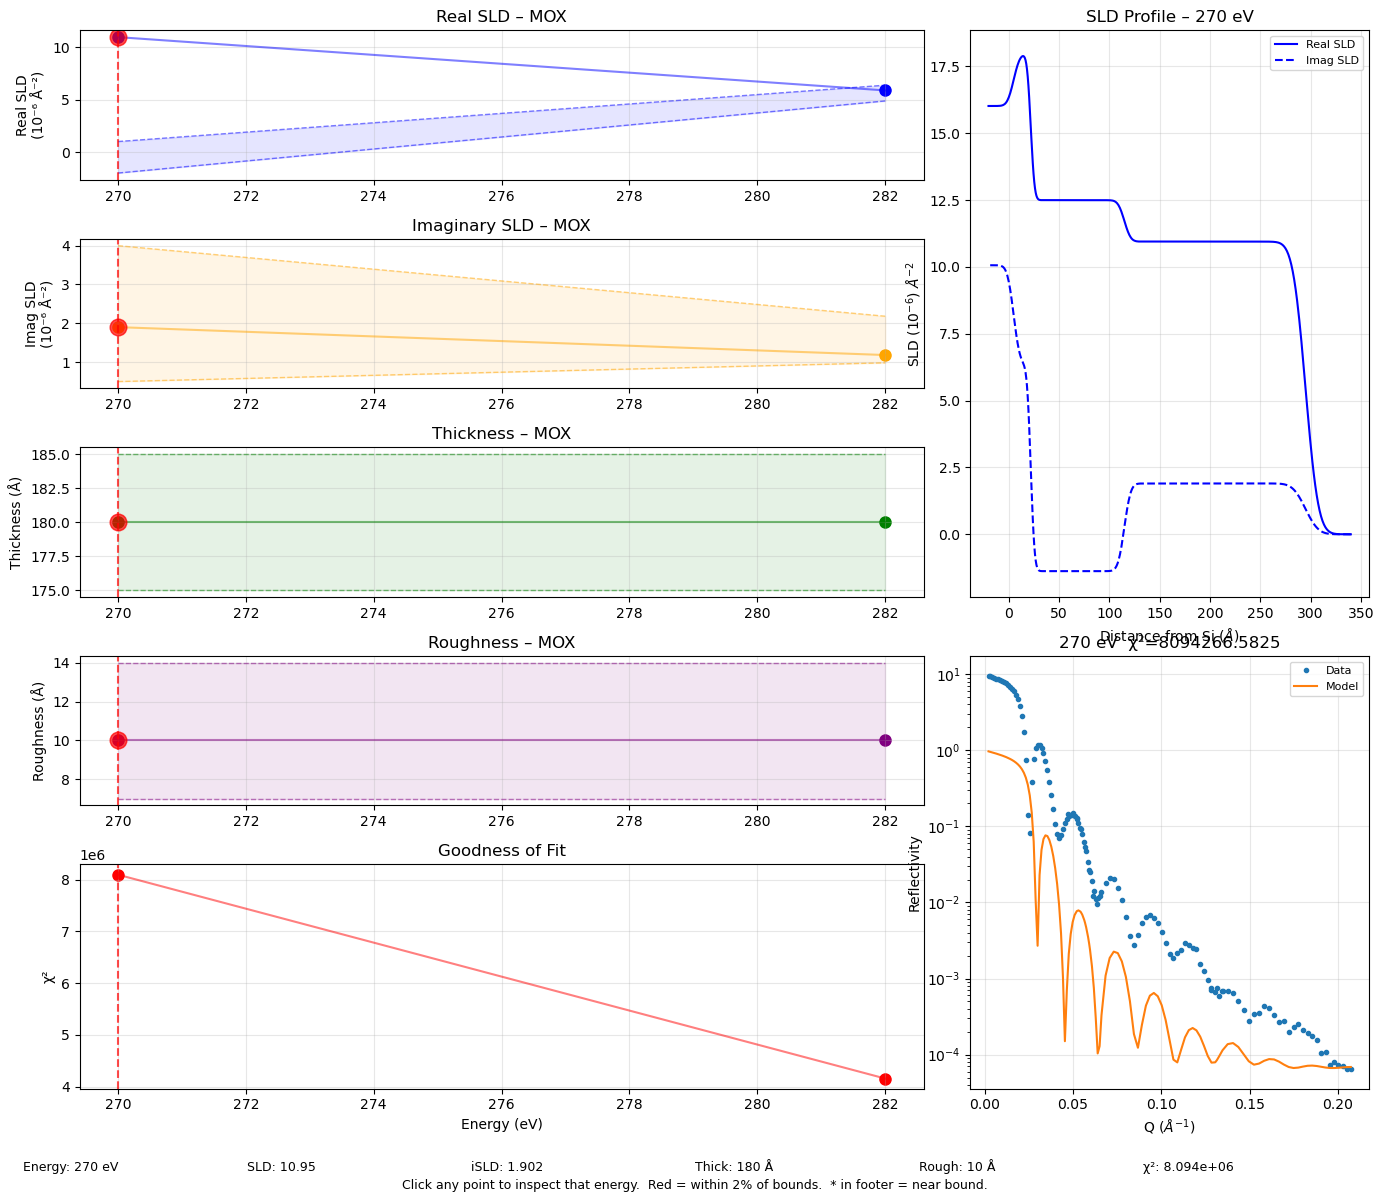

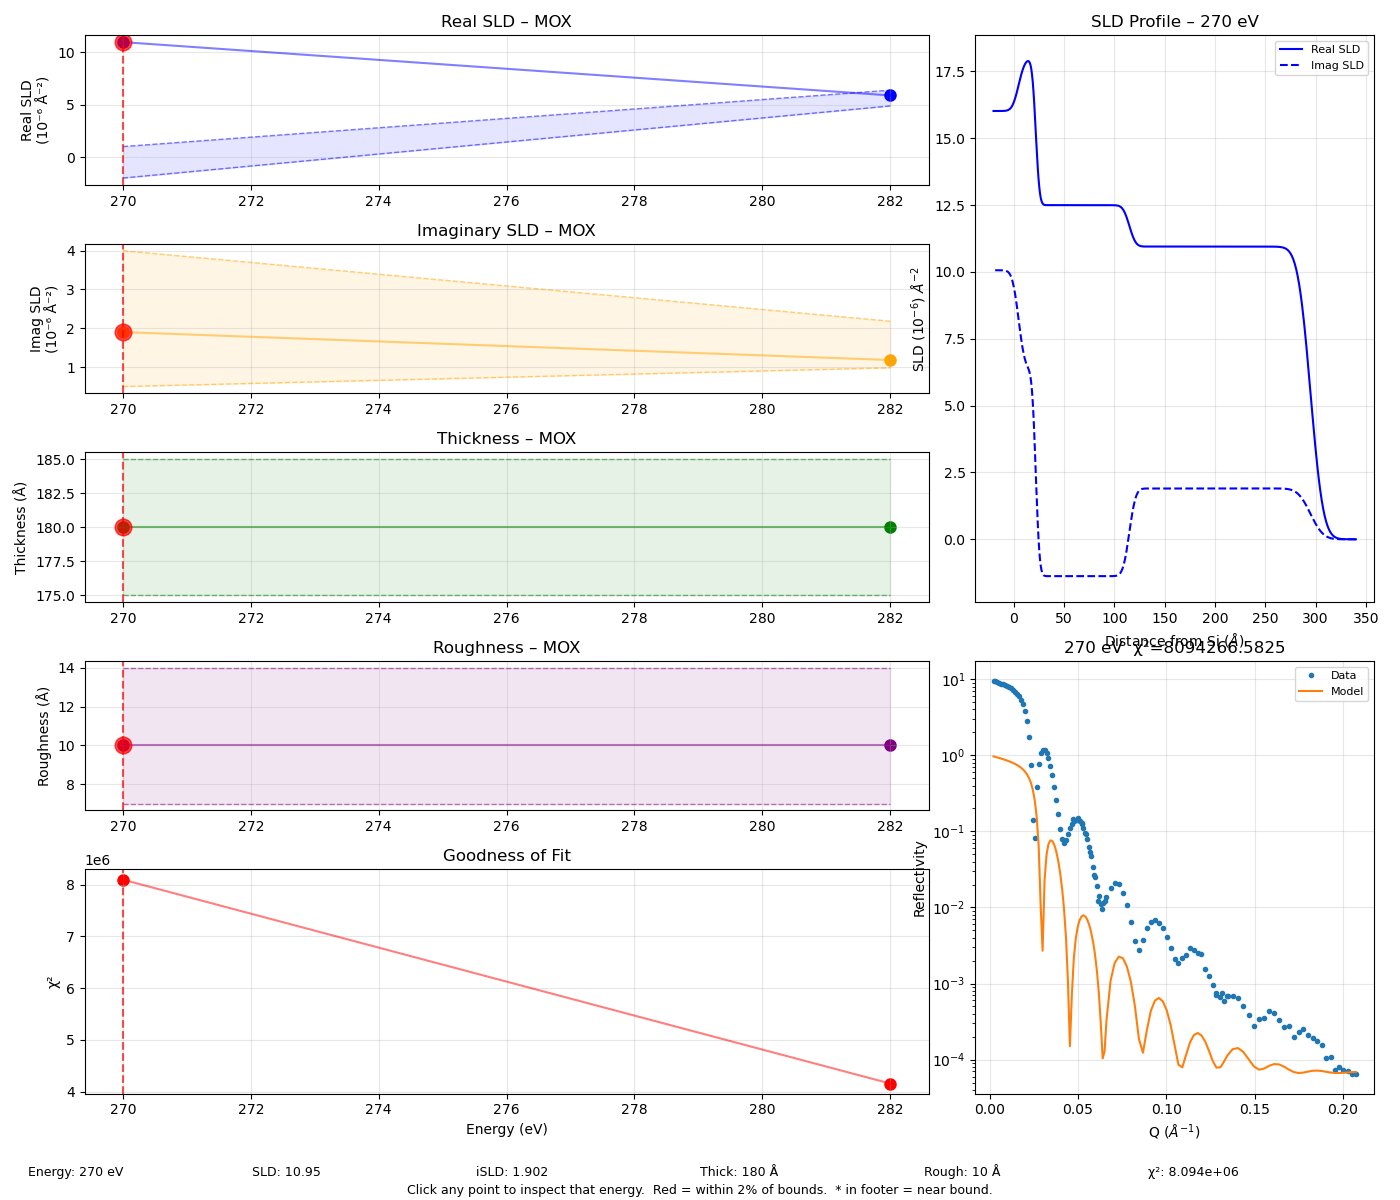

In [22]:
# ── BEFORE fitting: check starting values and bounds ──────────────────────
# Shows Real SLD, Imag SLD, Thickness, Roughness, and χ² vs energy.
# Shaded region = allowed bound range. Red points = within 2% of a bound.
# Click any point to update the reflectivity and SLD profile panels on the right.

create_vscode_parameter_explorer(
    objectives_dict=objectives_dict,   # your pre-fit objectives
    structures_dict=structures_dict,
    material_name='MOX',               # change to the material you want to inspect
    bound_threshold=0.02,              # 2% near-bound threshold
    figsize=(14, 12),
    # xlim=(270, 320),                 # optional: restrict energy axis
)

## 7. Adjust bounds interactively (optional)

Use `update_objective_with_plotting` to tweak a specific energy before fitting,
or `create_interactive_parameter_updater_v3` for a full interactive editor.

Updated MOX at 270.0 eV:
  sld_real bounds → (-2.0, 1.0), vary=True
  sld_imag bounds → (0.5, 4.0), vary=True


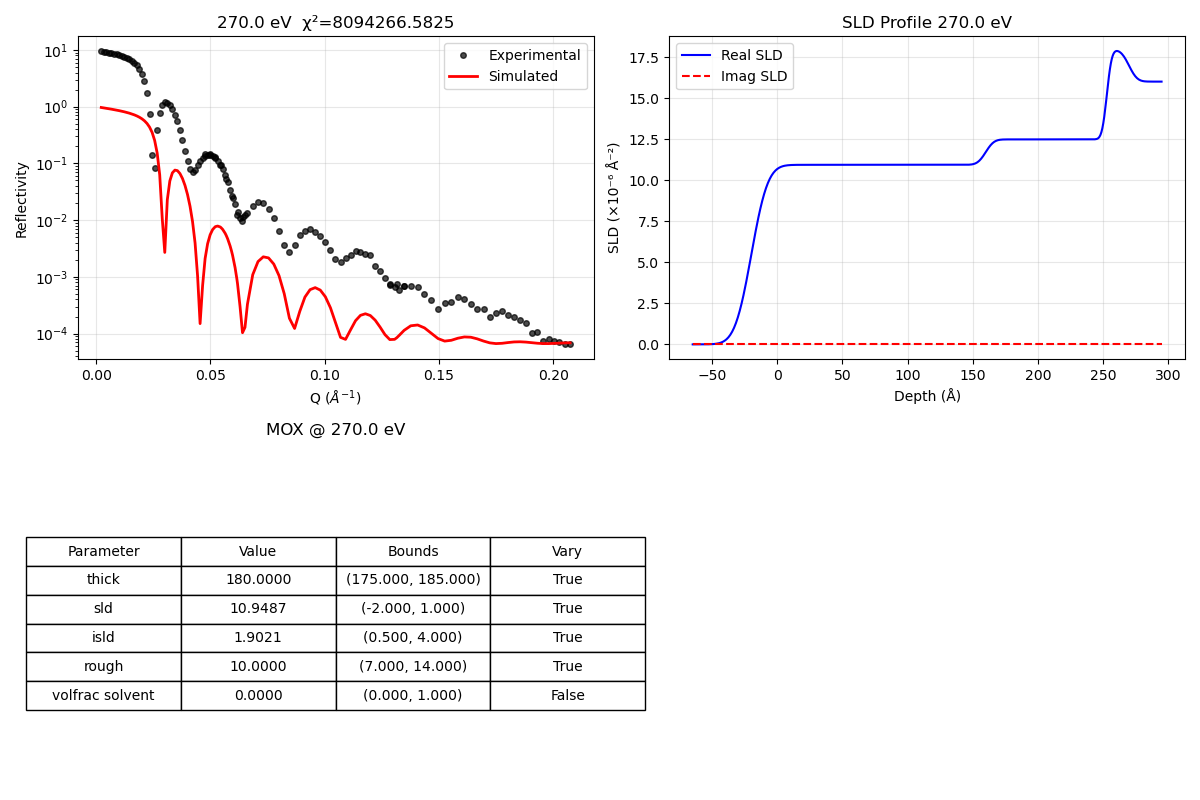

In [7]:
# Example: tighten SLD bounds for MOX at a specific energy
objectives_dict = update_objective_with_plotting(
    objectives_dict=objectives_dict,
    energy=270.0,
    material='MOX',
    updates={
        'sld_real_bounds': (-2.0, 1.0, True),
        'sld_imag_bounds': ( 0.5, 4.0, True),
    },
    plot=True,
    structures_dict=structures_dict,
)

## 8. Run batch fit

`batch_fit_selected_models` wraps `Model_Setup.batch_fit_selected_models_v2`.
Set `steps=0` to skip MCMC and do optimisation only.

In [8]:
SAVE_DIR = './fit_resultsthrowaway'

batch_results = batch_fit_selected_models(
    objectives_dict=objectives_dict,
    structures_dict=structures_dict,
    # energy_list=[285, 290],   # fit a subset; comment out for all
    method='differential_evolution',
    workers=-1,        # -1 = all available cores
    popsize=20,
    steps=0,         # MCMC steps (set 0 to skip)
    burn=0,          # burn-in steps to discard
    nwalkers=100,
    save_dir=SAVE_DIR,
    save_objectives=True,
    preserve_originals=True,
    verbose=True,
    model_name='Model1',
)

# Convenience unpacking
fitted_objectives   = batch_results['fitted_objectives']
original_objectives = batch_results['original_objectives']
individual_results  = batch_results['individual_results']
print('\nSummary stats:', batch_results['summary_stats'])

BATCH FITTING
Total: 2  |  To fit: 2  |  Pass-through: 0

--- 1/2: 270 eV ---
  Initial χ²: 8.09427e+06
Fitting model: Model1
Optimising with differential_evolution...


0it [00:00, ?it/s]/homes/dfs1/mambaforge/envs/refnxlocal/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
668604.0831401153: : 80it [00:19,  4.08it/s]


Optimisation done. χ² = 1.31963e+06
Saved objective → ./fit_resultsthrowaway/Model1_objective.pkl
Fitting complete: Model1
  Final χ²: 1.31963e+06  (improvement: 83.7%)

--- 2/2: 282 eV ---
  Initial χ²: 4.15807e+06
Fitting model: Model1
Optimising with differential_evolution...


146491.03654515106: : 84it [00:20,  4.11it/s]

Optimisation done. χ² = 290469
Saved objective → ./fit_resultsthrowaway/Model1_objective.pkl
Fitting complete: Model1
  Final χ²: 290469  (improvement: 93.0%)

Successful: 2  |  Failed: 0  |  Pass-through: 0
Overall χ² improvement: 86.9%

Summary stats: {'total_models': 2, 'total_objectives_in_output': 2, 'successful_fits': 2, 'failed_fits': 0, 'non_fitted_count': 0, 'initial_chi_squared_total': 12252340.31775998, 'final_chi_squared_total': 1610102.510031608, 'overall_improvement_percent': 86.85881661564905, 'save_directory': './fit_resultsthrowaway'}


## 9. Inspect results

In [9]:
# Print parameters for one energy
energy_to_inspect = energy_list[0]
print_fit_results(
    objective=fitted_objectives[energy_to_inspect],
    show_substrate=False,
)

χ² = 1.31963e+06


--- BACKGROUND ---
  bkg: 5.87155e-06 ± 1.6058e-06 (bounds: 6.46418e-08–0.000646418) (varying)

--- RESOLUTION ---
  dq - resolution: 1.8 (bounds: -inf–inf) (fixed)

--- ROUGHNESS ---
  MOX - rough: 7.00 Å ± 0.11 Å (bounds: 7.00–14.00 Å) (varying)
  UL - rough: 2.00 Å ± 0.09 Å (bounds: 2.00–9.00 Å) (varying)

--- SCALE ---
  scale: 4 ± 0.0154073 (bounds: 0.1–4) (varying)

--- SLD ---
  MOX - sld: -1.93182 ×10⁻⁶ Å⁻² ± 0.0087258 (bounds: -2–1) (varying)
  UL - sld: 15.4984 ×10⁻⁶ Å⁻² ± 0.0137441 (bounds: 9.49838–15.4984) (varying)

--- SLD_IMAG ---
  MOX - isld: 0.5 ×10⁻⁶ Å⁻² ± 0.00457395 (bounds: 0.5–4) (varying)
  UL - isld: 4.37817 ×10⁻⁶ Å⁻² ± 0.0146888 (bounds: 0–4.37817) (varying)

--- THICKNESS ---
  MOX - thick: 175.00 Å ± 0.10 Å (bounds: 175.00–185.00 Å) (varying)
  UL - thick: 98.00 Å ± 0.10 Å (bounds: 88.00–98.00 Å) (varying)


Click any point to update the reflectivity and SLD profile panels.


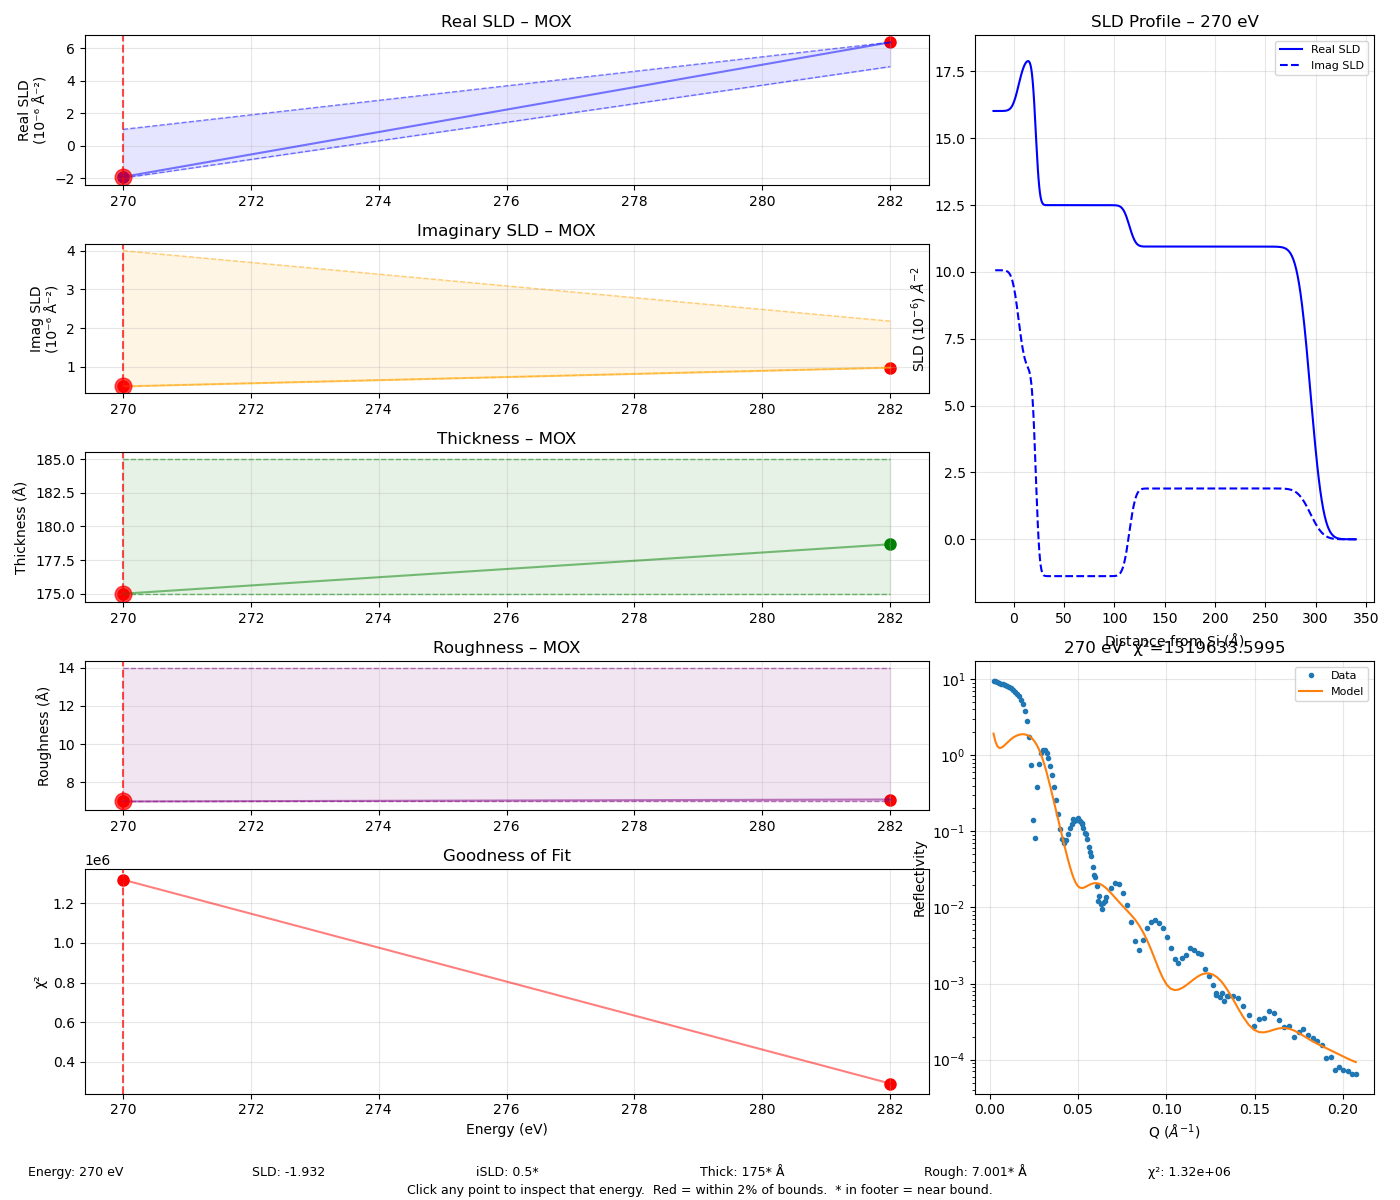

In [23]:
# ── AFTER fitting: inspect fitted parameters ──────────────────────────────
# Same explorer, but now fed the fitted objectives.
# Compare the point positions vs the shaded bound regions to see
# which parameters moved and whether any hit their bounds.

widget=create_vscode_parameter_explorer(
    objectives_dict=fitted_objectives,  # from batch_results['fitted_objectives']
    structures_dict=structures_dict,
    material_name='MOX',
    bound_threshold=0.02,
    figsize=(14, 12),
)

## 10. Save and reload results

In [14]:
# Save the complete batch results (objectives + MCMC chains)
save_path = save_batch_fit_results(
    batch_results=batch_results,
    filename='Model1_batch',
    save_dir=SAVE_DIR,
    include_objectives=True,
    include_mcmc_samples=True,
)
print(f'Saved to {save_path}')

Saved batch results → ./fit_resultsthrowaway/Model1_batch.pkl  (0.04 MB)
Saved to ./fit_resultsthrowaway/Model1_batch.pkl


In [15]:
# Reload in a fresh session
loaded = load_batch_fit_results(save_path)

# Convenience unpacking after reload
fitted_objectives   = loaded['fitted_objectives']
original_objectives = loaded['original_objectives']
individual_results  = loaded['individual_results']

Loaded: ./fit_resultsthrowaway/Model1_batch.pkl
  fitted_objectives: 2 entries
  original_objectives: 2 entries
  original_structures: 2 entries
  Energies: [270, 282]
  MCMC available for 0/2 energies


# Save SLDs 

Saved MOX SLD (2 energies) → /homes/dfs1/Reflectivity/INT_MOX/SLD_Fits/MOX_fittedtest.csv


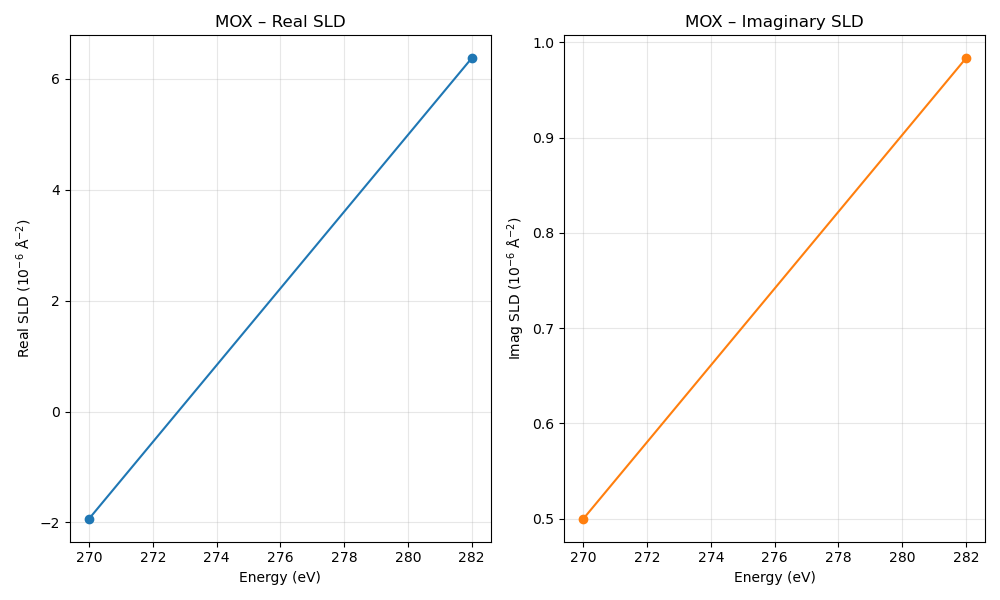

In [21]:
mox_array = save_material_sld(
    fitted_objectives,
    'MOX',
    "/homes/dfs1/Reflectivity/INT_MOX/SLD_Fits/MOX_fittedtest.csv",
    plot=True,
)



## Appendix: Single-energy fitting

For fitting or re-fitting a single energy outside of batch mode.

In [16]:
from copy import deepcopy

energy = 285.0
obj    = deepcopy(objectives_dict[energy])
s      = structures_dict[energy]

results = run_fitting(
    objective=obj,
    method='differential_evolution',
    workers=-1,
    popsize=20,
    steps=500,
    burn=200,
    save_dir=SAVE_DIR,
    save_objective=True,
    save_results=True,
    structure=s,
    model_name=f'Model1_{energy}eV',
    verbose=True,
)

print(f"\nFinal χ² = {results['optimized_chi_squared']:.4f}")
print_fit_results(obj)

KeyError: 285.0

## Appendix: Forward simulation (no fitting)

Useful for checking a model looks right before fitting,
or for generating reference curves.

In [ ]:
q_sim = np.linspace(0.01, 0.25, 500)

refl_dict, sim_structures, _ = simulate_reflectivity_profiles(
    energy_list=energy_list,
    material_sld_arrays=material_sld_arrays,
    constant_materials=None,
    base_layer_params=layer_params,
    layer_order=layer_order,
    q_values=q_sim,
    sample_name='Sample',
    dq=1.8,
    return_structures=True,
)

plot_simulated_reflectivity_and_sld(
    reflectivity_dict=refl_dict,
    structures_dict=sim_structures,
    profile_shift=-20,
)

## Appendix: Computing SLD from a chemical formula

Use `generate_sld_array_from_material` when you want to compute the
theoretical SLD for a known compound (e.g. for comparison or as a
starting point for the SLD arrays above).

In [ ]:
# Example: theoretical SLD for SiO2 across the carbon K-edge
energies_theory = np.arange(270, 320, 1.0)

SiO2_theory = generate_sld_array_from_material(
    formula='SiO2',
    density=2.2,            # g/cm³
    energy_list=energies_theory,
    probe='x-ray',
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(SiO2_theory[:, 0], SiO2_theory[:, 1], label='Real SLD')
axes[0].set_xlabel('Energy (eV)')
axes[0].set_ylabel(r'SLD ($10^{-6}$ Å$^{-2}$)')
axes[0].set_title('SiO₂ Real SLD')
axes[1].plot(SiO2_theory[:, 0], SiO2_theory[:, 2], color='C1', label='Imag SLD')
axes[1].set_xlabel('Energy (eV)')
axes[1].set_title('SiO₂ Imaginary SLD')
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()